In [ ]:
!pip install scanpy
!pip install anndata
!pip3 install igraph
!pip install celltypist
!pip install decoupler
!pip install fa2-modified
!pip install louvain
!pip install pertpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 68.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 70.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.8/121.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.4 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19876 sha256=a522ea4656e

In [ ]:
#Import core single cell datasets

import scanpy as sc
import anndata as ad
import numpy as np
import pertpy as pt

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
!mkdir -p PBMC
!cd PBMC

In [ ]:
pbmc_mtx = pt.dt.kang_2018()

Output()

In [ ]:
pbmc_mtx.shape

(24673, 15706)

In [ ]:
pbmc_mtx.to_df().to_csv('pbmc.csv')

In [ ]:
pbmc_mtx.obs.label.unique()

['ctrl', 'stim']
Categories (2, object): ['ctrl', 'stim']

In [ ]:
pbmc_mtx.obs.rename({"label": "condition"}, axis=1, inplace=True)
pbmc_mtx.obs["condition"].replace({"ctrl": "control", "stim": "stimulated"}, inplace=True)

/tmp/ipython-input-961429376.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pbmc_mtx.obs["condition"].replace({"ctrl": "control", "stim": "stimulated"}, inplace=True)
/tmp/ipython-input-961429376.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  pbmc_mtx.obs["condition"].replace({"ctrl": "control", "stim": "s

In [ ]:
pbmc_mtx.obs.condition.unique()

['control', 'stimulated']
Categories (2, object): ['control', 'stimulated']

In [ ]:
pbmc_mtx.obs.cell_type.value_counts()

,count
cell_type,
CD4 T cells,11238
CD14+ Monocytes,5697
B cells,2651
NK cells,1716
CD8 T cells,1621
FCGR3A+ Monocytes,1089
Dendritic cells,529
Megakaryocytes,132


In [ ]:
ag_rfc = pt.tl.Augur("random_forest_classifier")

In [ ]:
loaded_data = ag_rfc.load(pbmc_mtx, label_col="condition", cell_type_col="cell_type")
loaded_data

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'y_'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

In [ ]:
v_adata, v_results = ag_rfc.predict(
    loaded_data, subsample_size=50, select_variance_features=True, span=1
)

v_results["summary_metrics"]

! Set smaller span value in the case of a `segmentation fault` error.
! Set larger span in case of svddc or other near singularities error.


Output()

,CD14+ Monocytes,CD4 T cells,Dendritic cells,NK cells,CD8 T cells,B cells,FCGR3A+ Monocytes,Megakaryocytes
mean_augur_score,0.962468,0.725739,0.906783,0.715087,0.666344,0.834357,0.951414,0.488749
mean_auc,0.962468,0.725739,0.906783,0.715087,0.666344,0.834357,0.951414,0.488749
mean_accuracy,0.889828,0.657617,0.823464,0.649346,0.611040,0.742965,0.870582,0.504991
mean_precision,0.893741,0.679377,0.827669,0.658192,0.622147,0.784978,0.857924,0.516240
mean_f1,0.889611,0.642497,0.824429,0.646126,0.599674,0.723561,0.874997,0.412031
mean_recall,0.897402,0.635931,0.833922,0.661838,0.605490,0.691863,0.902206,0.366275


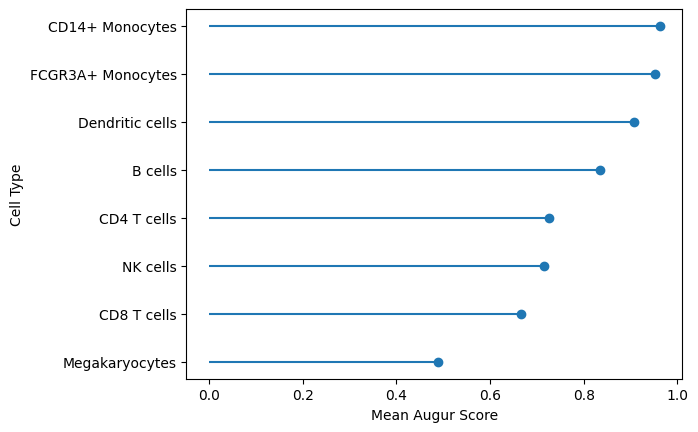

In [ ]:
lollipop = ag_rfc.plot_lollipop(v_results)


In [ ]:
sc.pp.neighbors(v_adata)
sc.tl.umap(v_adata)

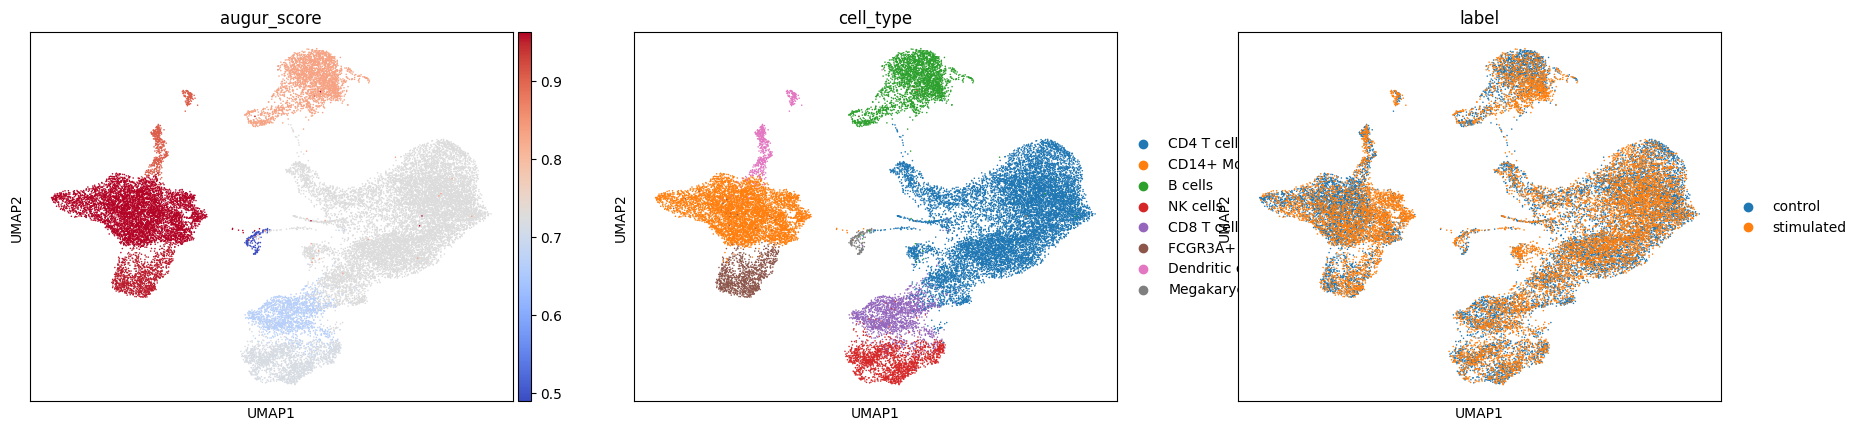

In [ ]:
sc.pl.umap(adata=v_adata, color=["augur_score", "cell_type", "label"], cmap='coolwarm')


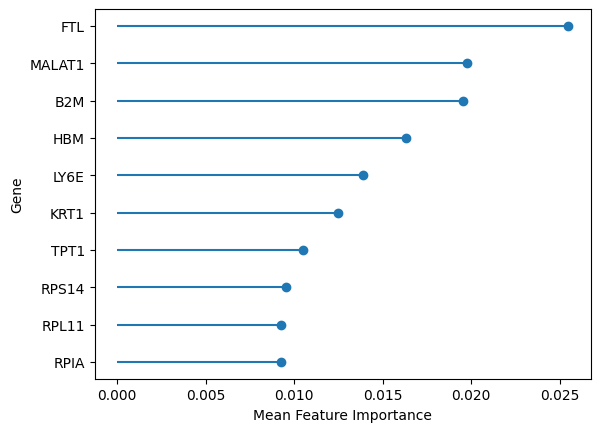

In [ ]:
important_features = ag_rfc.plot_important_features(v_results)

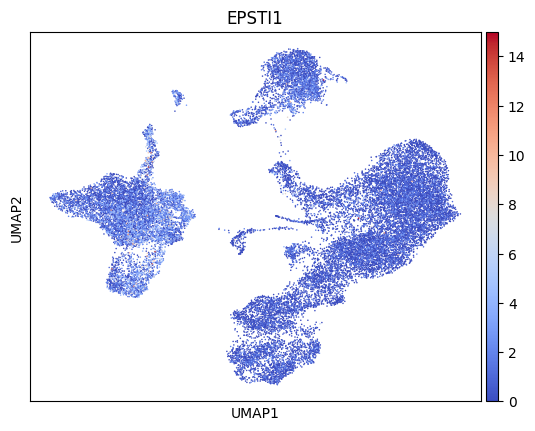

In [ ]:
sc.pl.umap(adata=v_adata, color=["EPSTI1"], cmap='coolwarm')

In [ ]:
v_results.keys()

dict_keys(['summary_metrics', 'feature_importances', 'full_results', 'CD14+ Monocytes', 'CD4 T cells', 'Dendritic cells', 'NK cells', 'CD8 T cells', 'B cells', 'FCGR3A+ Monocytes', 'Megakaryocytes'])

In [ ]:
v_results.get('feature_importances').head()

,genes,feature_importances,subsample_idx,fold,cell_type
0,TRMU,0.000000,0,0,CD14+ Monocytes
1,RAB14,0.001012,0,0,CD14+ Monocytes
2,ZNF91,0.000000,0,0,CD14+ Monocytes
3,UBE2L3,0.000131,0,0,CD14+ Monocytes
4,TBP,0.000000,0,0,CD14+ Monocytes


In [ ]:
feat_imp = v_results.get('feature_importances')

In [ ]:
feat_imp[feat_imp['cell_type'] == 'CD14+ Monocytes'].sort_values(by='feature_importances', ascending=False).head(10)

,genes,feature_importances,subsample_idx,fold,cell_type
129293,IRF7,0.027512,31,1,CD14+ Monocytes
165392,IRF7,0.026688,40,1,CD14+ Monocytes
162885,IRF7,0.024835,39,2,CD14+ Monocytes
93460,EPSTI1,0.021138,22,2,CD14+ Monocytes
159164,UBE2L6,0.019974,38,2,CD14+ Monocytes
189407,BST2,0.019820,46,1,CD14+ Monocytes
203430,EPSTI1,0.019333,49,2,CD14+ Monocytes
83744,BST2,0.018949,20,1,CD14+ Monocytes
2619,BST2,0.018942,0,1,CD14+ Monocytes
183638,MX2,0.018884,45,0,CD14+ Monocytes
